# V2a-RSNs Clustered IC Selection BSS Analysis

This notebook duplicates the shared linear BSS workflow for FastICA, Infomax, SOBI, and JADE,
but selects rejected ICs from spectral clusters instead of manually listing component indices.
Choose `DATASET_KEY`, `METHODS_TO_RUN`, and the cluster-selection settings below. Outputs are saved
under `outputs/linear/v2a-RSNs/clustered/<dataset_group>/<data_name>/<method>/` when `SAVE_OUTPUTS = True`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    p
    for p in candidates
    if (p / "pyproject.toml").exists() and (p / "src" / "bss_notebook.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
CORE_DIR = SRC_DIR / "core"
for path in (SRC_DIR, CORE_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from bss_notebook import (
    BSS_METHODS,
    available_datasets,
    load_traces,
    output_directory,
    run_bss_method,
    save_bss_outputs,
    summarize_results,
)
from ica_utils import (
    cluster,
    rank_clusters_by_mean_log_psd,
    reconstruct_bss,
    reject_components_from_cluster_selection,
)
from visualization import plot_clusters

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PROJECT_ROOT



PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising')

In [2]:
available_datasets(PROJECT_ROOT)


,key,group,data_name,trace_path,exists,default_n_components,sample_rate_hz,notes
0,motorneurons/fish3_trace2_dff,motorneurons,fish3_trace2_dff,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Motorneuron dF/F traces.
1,motorneurons/gcM_restored,motorneurons,gcM_restored,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Restored motorneuron traces.
2,v2a-RSNs/220127_F4_run2_fluorescence,v2a-RSNs,220127_F4_run2_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces.
3,v2a-RSNs/220127_F4_run2_spike_rate,v2a-RSNs,220127_F4_run2_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces.
4,v2a-RSNs/220210_F1_run6_fluorescence,v2a-RSNs,220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces. Uses frameRateSCA...
5,v2a-RSNs/220210_F1_run6_spike_rate,v2a-RSNs,220210_F1_run6_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces. Uses frameRateSCAPE...


In [ ]:
# Dataset and method selection
DATASET_KEY = "v2a-RSNs/220127_F4_run2_fluorescence"

# Use list(BSS_METHODS) to run all four methods, or choose a subset such as ["fastica"].
METHODS_TO_RUN = ["fastica", "infomax"] # list(BSS_METHODS)

# Decomposition settings. n_components is fixed later to n_neurons (one IC per trace).
DECOMPOSITION_TOL = 0.0001
DECOMPOSITION_MAX_ITER = 500
DECOMPOSITION_RANDOM_STATE = 0

# Cluster ICs by Welch-spectrum features, matching the reference ICA notebook's clustering workflow.
N_CLUSTERS = 7
CLUSTER_FEATURE_START_BIN = 30
CLUSTER_NPERSEG = 250
CLUSTER_NOVERLAP = 125


# Keep False until cluster rejection choices are final.
SAVE_OUTPUTS = False

# Output layout root: outputs/linear/v2a-RSNs/clustered/v2a-RSNs/<data_name>/<method>/
ANALYSIS_KIND = "linear/v2a-RSNs/clustered"



In [4]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
n_neurons, n_frames = traces.shape
sample_rate_hz = dataset.sample_rate_hz or 1.0
n_components = n_neurons

print(f"dataset: {dataset.key}")
print(f"trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"traces: neurons={n_neurons}, frames={n_frames}")
print(f"methods: {METHODS_TO_RUN}")
print(f"decomposition n_components (fixed to number of traces): {n_components}")
print(f"sample_rate_hz: {sample_rate_hz}")
for method in METHODS_TO_RUN:
    out_dir = output_directory(
        method,
        dataset.data_name,
        PROJECT_ROOT,
        analysis_kind=ANALYSIS_KIND,
        dataset_group=dataset.group,
    )
    print(f"{method} output dir: {out_dir.relative_to(PROJECT_ROOT)}")



dataset: v2a-RSNs/220127_F4_run2_fluorescence
trace file: data/v2a-RSNs/new_data_09112022/220127_F4_run2/220127_F4_F4_run2_after_dec_cells_fluorescence_signals.npy
traces: neurons=844, frames=3176
methods: ['fastica', 'infomax']
decomposition n_components (fixed to number of traces): 844
sample_rate_hz: 5.2962
fastica output dir: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica
infomax output dir: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/infomax


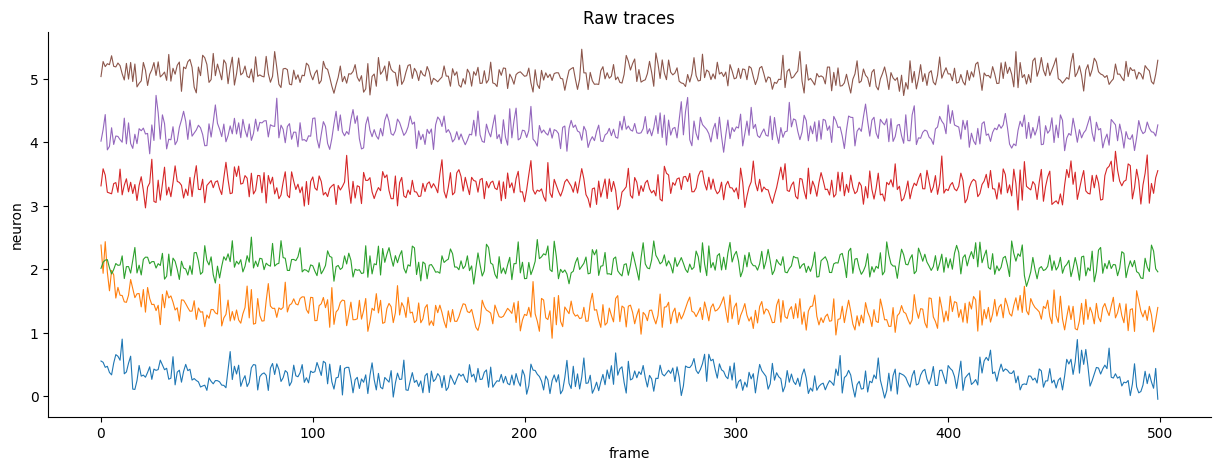

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
time_slice = slice(0, min(500, n_frames))
shown_neurons = list(range(min(6, n_neurons)))
offset = np.nanstd(traces[:, time_slice]) * 0.4
if not np.isfinite(offset) or offset == 0:
    offset = 1.0

for row_idx, neuron_idx in enumerate(shown_neurons):
    ax.plot(
        np.arange(time_slice.start, time_slice.stop),
        traces[neuron_idx, time_slice] + row_idx * offset,
        lw=0.8,
    )

ax.set_title("Raw traces")
ax.set_xlabel("frame")
ax.set_ylabel("neuron")
ax.set_yticks([row_idx * offset for row_idx in range(len(shown_neurons))])
ax.set_yticklabels([str(neuron_idx) for neuron_idx in shown_neurons]);


In [6]:
import time

results = {}
total_methods = len(METHODS_TO_RUN)
run_start = time.perf_counter()

for idx, method in enumerate(METHODS_TO_RUN, start=1):
    t0 = time.perf_counter()
    print(f"[{idx}/{total_methods}] Starting decomposition for {method}...")
    results[method] = run_bss_method(
        dataset_key=DATASET_KEY,
        method=method,
        n_components=n_components,
        reject_components=(),
        save_outputs=False,
        project_root=PROJECT_ROOT,
        tol=DECOMPOSITION_TOL,
        max_iter=DECOMPOSITION_MAX_ITER,
        random_state=DECOMPOSITION_RANDOM_STATE,
        analysis_kind=ANALYSIS_KIND,
    )
    dt = time.perf_counter() - t0
    print(f"[{idx}/{total_methods}] Finished {method} in {dt:.1f}s")

print(f"Completed decomposition for {total_methods} methods in {time.perf_counter() - run_start:.1f}s")
summarize_results(results)



[1/2] Starting decomposition for fastica...


/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/.venv/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


[1/2] Finished fastica in 126.4s
[2/2] Starting decomposition for infomax...
[2/2] Finished infomax in 1.5s
Completed decomposition for 2 methods in 127.9s


,method,dataset_key,data_name,dataset_group,input_shape,components_shape,cleaned_shape_frames_by_neurons,output_dir,saved
0,fastica,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(3176, 844)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False
1,infomax,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,v2a-RSNs,"(844, 3176)","(3176, 844)","(3176, 844)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False


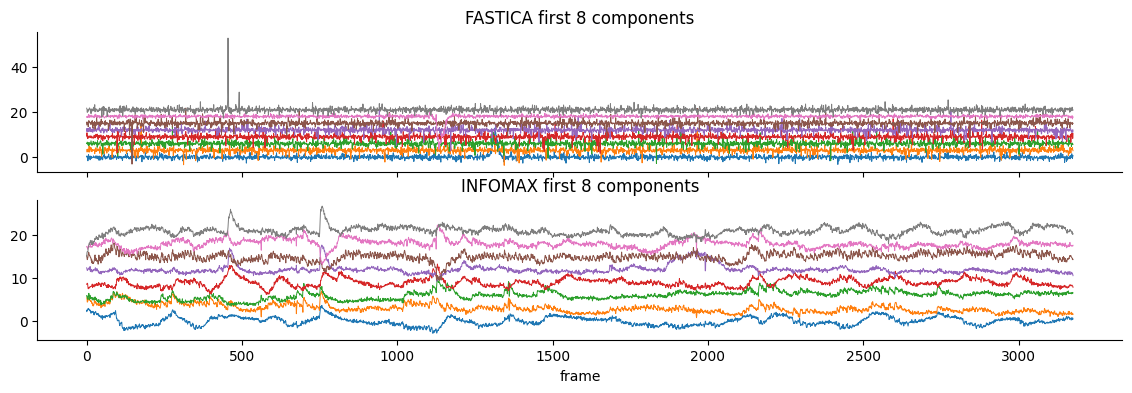

In [7]:
component_count = min(8, n_components)
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.0 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, (method, result) in zip(axes, results.items()):
    for comp_idx in range(component_count):
        ax.plot(result.ic_comps[:, comp_idx] + comp_idx * 3, lw=0.7, label=f"IC {comp_idx}")
    ax.set_title(f"{method.upper()} first {component_count} components")
axes[-1].set_xlabel("frame");


In [8]:
import time

cluster_results = {}
cluster_rows = []
total_methods = len(results)
cluster_start = time.perf_counter()

for idx, (method, result) in enumerate(results.items(), start=1):
    t0 = time.perf_counter()
    print(f"[{idx}/{total_methods}] Clustering ICs for {method}...")
    new_mat, predictions, spectra, features = cluster(
        result.ic_comps,
        N_CLUSTERS,
        sample_rate_hz,
        feature_start_bin=CLUSTER_FEATURE_START_BIN,
        nperseg=CLUSTER_NPERSEG,
        noverlap=CLUSTER_NOVERLAP,
        random_state=DECOMPOSITION_RANDOM_STATE,
    )
    cluster_results[method] = {
        "new_mat": new_mat,
        "predictions": predictions,
        "spectra": spectra,
        "features": features,
    }
    for cluster_id in sorted(np.unique(predictions)):
        ic_indices = np.flatnonzero(predictions == cluster_id)
        cluster_rows.append(
            {
                "method": method,
                "cluster": int(cluster_id),
                "n_ics": int(ic_indices.size),
                "ic_indices": ic_indices.tolist(),
            }
        )
    dt = time.perf_counter() - t0
    print(f"[{idx}/{total_methods}] Finished clustering {method} in {dt:.1f}s")

print(f"Completed clustering for {total_methods} methods in {time.perf_counter() - cluster_start:.1f}s")
pd.DataFrame(cluster_rows)



[1/2] Clustering ICs for fastica...
[1/2] Finished clustering fastica in 1.7s
[2/2] Clustering ICs for infomax...
[2/2] Finished clustering infomax in 1.4s
Completed clustering for 2 methods in 3.1s


,method,cluster,n_ics,ic_indices
0,fastica,0,159,"[9, 10, 17, 20, 22, 26, 36, 37, 40, 45, 52, 66..."
1,fastica,1,142,"[12, 27, 28, 30, 39, 42, 51, 68, 71, 77, 90, 9..."
2,fastica,2,76,"[6, 13, 14, 18, 34, 44, 49, 53, 56, 61, 88, 10..."
3,fastica,3,122,"[7, 8, 15, 19, 24, 25, 29, 32, 41, 50, 59, 63,..."
4,fastica,4,145,"[1, 3, 4, 11, 16, 33, 47, 48, 58, 62, 69, 70, ..."
5,fastica,5,169,"[2, 5, 21, 23, 35, 38, 43, 46, 54, 55, 57, 60,..."
6,fastica,6,31,"[0, 31, 89, 138, 151, 152, 162, 209, 226, 249,..."
7,infomax,0,181,"[61, 64, 67, 71, 72, 74, 76, 79, 80, 81, 84, 8..."
8,infomax,1,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
9,infomax,2,197,"[153, 201, 205, 212, 218, 220, 227, 230, 234, ..."


fastica
  Peak log-PSD rank near 0 Hz (high→low): [2, 6, 3, 4, 5, 1, 0]


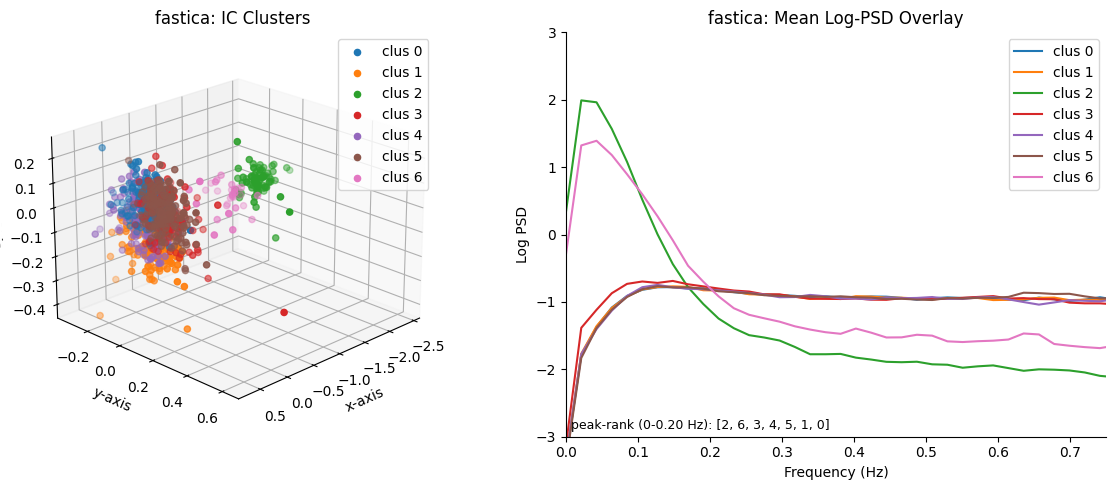

infomax
  Peak log-PSD rank near 0 Hz (high→low): [1, 5, 3, 0, 2, 6, 4]


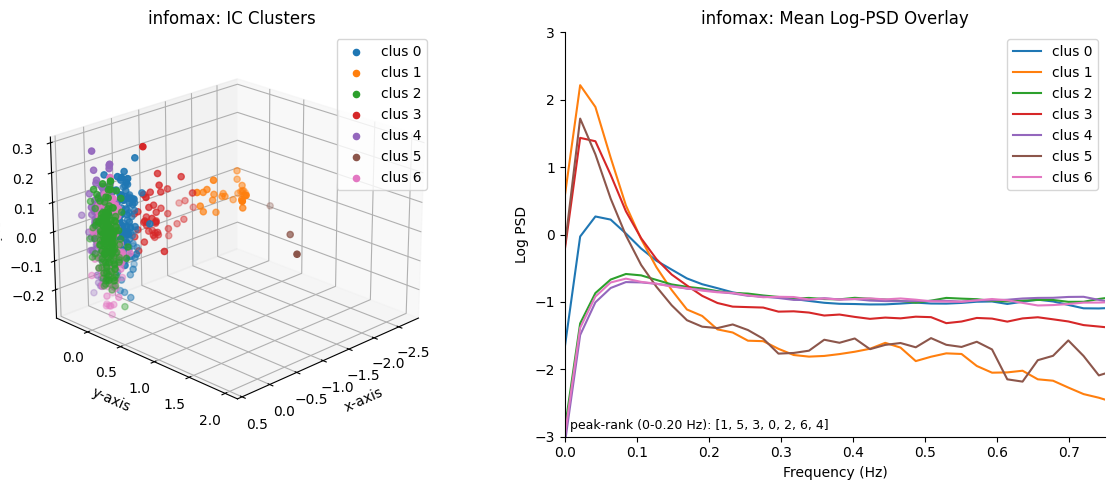

In [9]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

for method, clustered in cluster_results.items():
    print(method)

    new_mat = clustered["new_mat"]
    predictions = clustered["predictions"]
    spectra = clustered["spectra"]

    ranked = rank_clusters_by_mean_log_psd(
        spectra,
        predictions,
        sample_rate_hz,
        fmin=0.0,
        fmax=0.20,
        aggregate="peak",
    )
    ordered_clusters = [row["cluster"] for row in ranked]
    print(f"  Peak log-PSD rank near 0 Hz (high→low): {ordered_clusters}")

    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.0])

    # Left: 3D cluster scatter
    ax3d = fig.add_subplot(gs[0, 0], projection="3d")
    for label in np.unique(predictions):
        pts = new_mat[predictions == label]
        ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], label=f"clus {int(label)}")
    ax3d.set_xlabel("x-axis")
    ax3d.set_ylabel("y-axis")
    ax3d.set_zlabel("z-axis")
    ax3d.set_title(f"{method}: IC Clusters")
    ax3d.legend(loc="best")
    ax3d.view_init(elev=22, azim=45)

    # Right: overlay of mean log-PSDs only
    ax_psd = fig.add_subplot(gs[0, 1])
    eps = np.finfo(float).eps
    freqs = np.linspace(0.0, float(sample_rate_hz) / 2.0, spectra.shape[1])
    for label in np.unique(predictions):
        group = spectra[predictions == label]
        mean_log = np.log(np.maximum(group.mean(axis=0), eps))
        ax_psd.plot(freqs, mean_log, lw=1.5, label=f"clus {int(label)}")

    ax_psd.set_xlim([0, 0.75])
    ax_psd.set_ylim([-3, 3])
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("Log PSD")
    ax_psd.set_title(f"{method}: Mean Log-PSD Overlay")
    ax_psd.text(0.01, 0.02, f"peak-rank (0-0.20 Hz): {ordered_clusters}", transform=ax_psd.transAxes, fontsize=9)
    ax_psd.legend(loc="best")

    fig.tight_layout()
    display(fig)
    plt.close(fig)



In [10]:
# Keep False until cluster rejection choices are final.
SAVE_OUTPUTS = True

# Fill after inspecting the 3D cluster plots. If keep_clusters is non-empty, all other clusters are rejected.
CLUSTER_SELECTION_BY_METHOD = {
    "fastica": {"reject_clusters": [], "keep_clusters": [2,6,3,4]},
    "infomax": {"reject_clusters": [], "keep_clusters": [1,5,3,0]},
}

In [11]:
clustered_cleaned = {}
reject_components_by_method = {}
accepted_components_by_method = {}
accepted_counts_by_method = {}
selection_rows = []

for method, result in results.items():
    selection = CLUSTER_SELECTION_BY_METHOD.get(method, {})
    predictions = cluster_results[method]["predictions"]
    reject_components = reject_components_from_cluster_selection(
        predictions,
        reject_clusters=selection.get("reject_clusters", []),
        keep_clusters=selection.get("keep_clusters", []),
    )
    all_components = np.arange(predictions.size, dtype=int)
    accepted_components = np.setdiff1d(all_components, reject_components)

    reject_components_by_method[method] = reject_components.tolist()
    accepted_components_by_method[method] = accepted_components.tolist()
    accepted_counts_by_method[method] = int(accepted_components.size)

    clustered_cleaned[method] = reconstruct_bss(
        result.ic_comps,
        result.A,
        result.mean,
        reject=reject_components,
    )
    selection_rows.append(
        {
            "method": method,
            "reject_clusters": selection.get("reject_clusters", []),
            "keep_clusters": selection.get("keep_clusters", []),
            "accept_components": accepted_components.tolist(),
            "n_accepted": int(accepted_components.size),
            "reject_components": reject_components.tolist(),
            "n_rejected": int(reject_components.size),
        }
    )

selection_df = pd.DataFrame(selection_rows)
print("Effective n_components per method (from accepted clusters):")
display(selection_df[["method", "n_accepted", "n_rejected", "keep_clusters", "reject_clusters"]])
selection_df



Effective n_components per method (from accepted clusters):


,method,n_accepted,n_rejected,keep_clusters,reject_clusters
0,fastica,374,470,"[2, 6, 3, 4]",[]
1,infomax,260,584,"[1, 5, 3, 0]",[]


,method,reject_clusters,keep_clusters,accept_components,n_accepted,reject_components,n_rejected
0,fastica,[],"[2, 6, 3, 4]","[0, 1, 3, 4, 6, 7, 8, 11, 13, 14, 15, 16, 18, ...",374,"[2, 5, 9, 10, 12, 17, 20, 21, 22, 23, 26, 27, ...",470
1,infomax,[],"[1, 5, 3, 0]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",260,"[153, 182, 201, 205, 206, 208, 211, 212, 213, ...",584


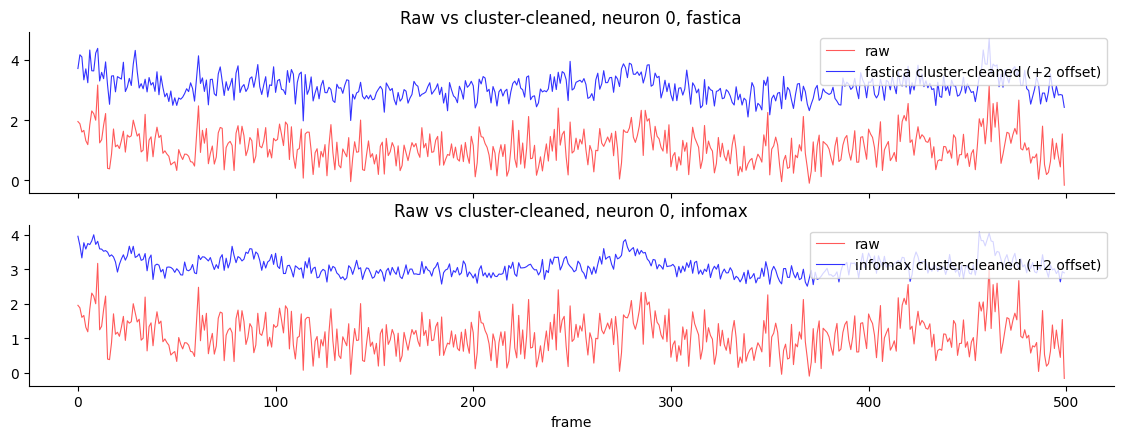

In [12]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.3 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
neuron_idx = 0
raw_vs_cleaned_offset = 2
for ax, (method, result) in zip(axes, results.items()):
    raw_trace = traces[neuron_idx, time_slice]
    cleaned_trace = clustered_cleaned[method][time_slice, neuron_idx]
    ax.plot(raw_trace, lw=0.8, label="raw", color="red", alpha=0.65)
    ax.plot(
        cleaned_trace + raw_vs_cleaned_offset,
        lw=0.8,
        label=f"{method} cluster-cleaned (+{raw_vs_cleaned_offset:g} offset)",
        color="blue",
        alpha=0.8,
    )
    ax.set_title(f"Raw vs cluster-cleaned, neuron {neuron_idx}, {method}")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("frame");


In [13]:
saved_paths_by_method = {}

if SAVE_OUTPUTS:
    for method, result in results.items():
        out_dir = output_directory(
            method,
            result.dataset.data_name,
            PROJECT_ROOT,
            analysis_kind=ANALYSIS_KIND,
            dataset_group=result.dataset.group,
        )
        saved_paths_by_method[method] = save_bss_outputs(
            spec=result.dataset,
            method=method,
            traces=result.traces,
            ic_comps=result.ic_comps,
            IC_ft=result.IC_ft,
            A=result.A,
            mean=result.mean,
            cleaned=clustered_cleaned[method],
            reject_components=reject_components_by_method[method],
            output_dir=out_dir,
            n_components=accepted_counts_by_method[method],
            tol=DECOMPOSITION_TOL,
            max_iter=DECOMPOSITION_MAX_ITER,
            random_state=DECOMPOSITION_RANDOM_STATE,
        )

for method, result in results.items():
    accepted_count = accepted_counts_by_method.get(method)
    if accepted_count is not None:
        print(f"{method}: accepted components count = {accepted_count}")
    if method in saved_paths_by_method:
        print(f"{method}:")
        for label, path in saved_paths_by_method[method].items():
            print(f"  {label}: {path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"{method}: not saved; set SAVE_OUTPUTS = True after cluster selections are final "
            f"to write outputs under {result.output_dir.relative_to(PROJECT_ROOT)}"
        )



fastica: accepted components count = 374
fastica:
  cleaned: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/cleaned_fastica_220127_F4_run2_fluorescence.npy
  components: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/components_fastica_220127_F4_run2_fluorescence.npy
  spectra: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/spectra_fastica_220127_F4_run2_fluorescence.npy
  mixing: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/mixing_fastica_220127_F4_run2_fluorescence.npy
  mean: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/mean_fastica_220127_F4_run2_fluorescence.npy
  metadata: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fluorescence/fastica/metadata_fastica_220127_F4_run2_fluorescence.json
infomax: accepted components count = 260
infomax:
  cleaned: outputs/linear_v2a-RSNs_clustered/v2a-RSNs/220127_F4_run2_fl